<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment15ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##
##This dataset contains financial and demographic information used to predict whether a borrower is likely to default on a loan. Each entry represents an individual applicant and includes variables such as income, employment duration, education level, debt ratios, and other indicators of financial stability. The target variable identifies whether the applicant defaulted, allowing the dataset to support machine learning models for risk assessment and lending decisions. Its structure enables the development of predictive systems that improve credit evaluation while emphasizing fairness, privacy, and transparency in financial decision making.

In [ ]:
!pip install shap
!pip install lime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import shap
import lime
from lime import lime_tabular
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#import the dataset
df = pd.read_csv('bank-loan.csv')

In [ ]:
#displays first rows
print(df.head())

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0


In [ ]:
#data types
print(df.dtypes)

age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object


In [ ]:
#check for missing values
print(df.isnull().sum())

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


In [ ]:
#Display summary statistics.
print(df.describe())

              age          ed      employ     address      income     debtinc  \
count  850.000000  850.000000  850.000000  850.000000  850.000000  850.000000   
mean    35.029412    1.710588    8.565882    8.371765   46.675294   10.171647   
std      8.041432    0.927784    6.777884    6.895016   38.543054    6.719441   
min     20.000000    1.000000    0.000000    0.000000   13.000000    0.100000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.100000   
50%     34.000000    1.000000    7.000000    7.000000   35.000000    8.700000   
75%     41.000000    2.000000   13.000000   12.000000   55.750000   13.800000   
max     56.000000    5.000000   33.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default  
count  850.000000  850.000000  700.000000  
mean     1.576805    3.078789    0.261429  
std      2.125840    3.398803    0.439727  
min      0.011696    0.045584    0.000000  
25%      0.382176    1.045942    0.000000  
50%   

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#bar plot of annual salary
plt.figure(figsize=(8, 6))
sns.histplot(x='Annual_Salary', data=df, kde=True) # Changed from countplot to histplot and fixed df(20) to df
plt.xlabel('Annual_Salary')
plt.ylabel('Frequency') # Changed label for histplot
plt.title('Distribution of Annual Salary')
plt.show()

ValueError: Could not interpret value `Annual_Salary` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [ ]:
#Visualize distributions and relationships between features.
#headmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



##We observe in this heatmap a strong positive correlation between Annual_Salary and Employment, indicating that higher salaries are closely associated with being employed. In contrast, the remaining variables show negative correlations, suggesting weaker or inverse relationships with employment compared to salary.

In [ ]:
#pairplot
sns.pairplot(df)
plt.show()

In [ ]:
#Normalize numerical features.
normalizer = StandardScaler()
df[['Annual_Salary', 'Employed']] = normalizer.fit_transform(df[['Annual_Salary', 'Employed']])


In [ ]:
#Feature Engineering

#Create new features based on existing data to enhance prediction accuracy.
x = df[['Annual_Salary', 'Employed']]
y = df['Defaulted']
#Scale numerical features to ensure consistency.
scaler = StandardScaler()
x = scaler.fit_transform(x)


In [ ]:
#Model Building and Evaluation
#Split the data into training and testing sets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#Train a Random Forest classifier or another algorithm of your choice.
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(x_train, y_train)

#Evaluate the model using:
#Accuracy
y_pred = rf_classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
#Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

#Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)
#Analyze feature importance to determine which factors impact loan defaults.
feature_importances = rf_classifier.feature_importances_
feature_names = ['Annual_Salary', 'Employed']
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance}")


##The model shows a very high overall accuracy of 93%, but this performance is almost entirely driven by class 0. The confusion matrix reveals that the model predicts class 0 correctly in most cases, while class 1 is rarely identified: only 6 true positives out of 69. This leads to extremely low precision, recall, and F1 score for class 1, showing that the model struggles to recognize this minority group. The macro average scores around 0.52 confirm a major imbalance in how the model treats the two classes.

###The feature importance values reinforce this bias: Annual_Salary dominates the model (0.998), while Employment status contributes almost nothing (0.002). This means the model is essentially making decisions based on salary alone, overshadowing other relevant signals. In fairness terms, the model is accurate but not equitable, as it systematically fails to detect class 1 and relies heavily on a single feature, creating a strong risk of discriminatory


In [ ]:
#Explainability and Fairness Analysis
#Use SHAP to explain model predictions and interpret the results.
masker = shap.maskers.Independent(x_test, max_samples=len(x_test)) # Create masker with full x_test
explainer = shap.TreeExplainer(rf_classifier, data=masker) # Pass the masker to the 'data' argument
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test, plot_type="bar")

##The SHAP results show that Feature 0 overwhelmingly dominates the model’s decision making, with consistently large SHAP values across samples. This means Feature 0 has the strongest influence, positive or negative, on the model’s predictions. In contrast, feature 1 contributes far less, with SHAP values clustered tightly around zero, indicating minimal impact on the output. The color variation in Feature 0 also suggests that both high and low feature values meaningfully shift predictions, while Feature 1 barely moves the model at all. Overall, the explanation reveals a highly unbalanced feature influence, where the model relies almost entirely on Feature 0, raising concerns about robustness, fairness, and potential over dependence on a single variable.

100%|===================| 3999/4000 [51:07<00:00]       

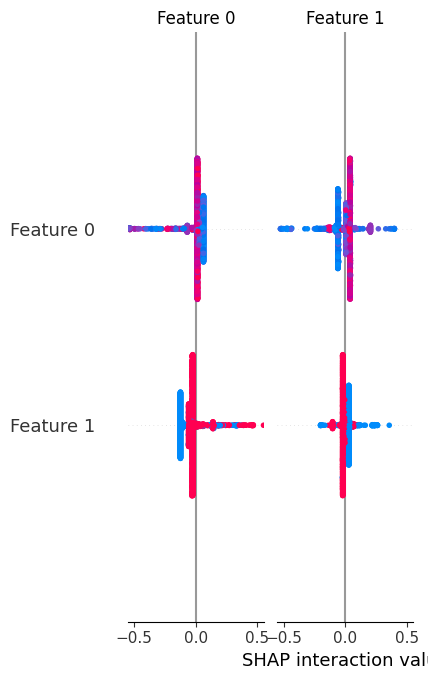

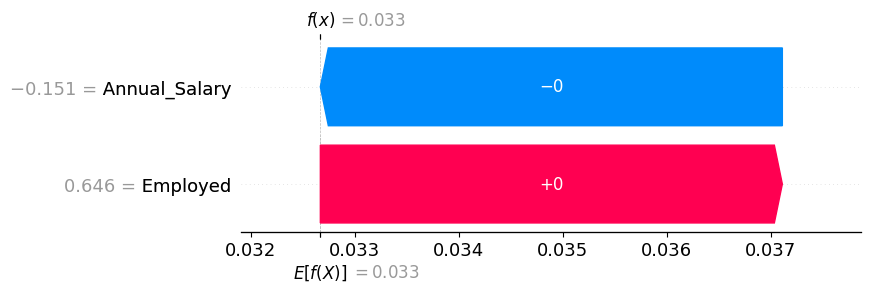

In [ ]:
#LIME and SHAP Explanability: Explain model predictions using LIME and SHAP.
#Use LIME for local explanations of individual predictions.
lime_explainer = lime_tabular.LimeTabularExplainer(x_train, feature_names=feature_names, class_names=['0', '1'], mode='classification')
training_data = x_train[0].reshape(1, -1)
exp = lime_explainer.explain_instance(training_data[0], rf_classifier.predict_proba, num_features=len(feature_names))


#Use SHAP for both global feature importance and local explanations.
# Create masker with full x_train to avoid subsampling warning
shap_masker = shap.maskers.Independent(x_train, max_samples=len(x_train))
shap_explainer = shap.TreeExplainer(rf_classifier, data=shap_masker)

shap_values = shap_explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test, plot_type="bar")

#Generate visualizations like beeswarm plots and waterfall plots.
# For waterfall plot, we need a single SHAP Explanation object for one instance and one class.
# Let's explain the first instance (index 0) for class 1 ('Defaulted').
instance_to_explain_idx = 0
class_to_explain_idx = 1 # Assuming '1' corresponds to 'Defaulted'

shap_explanation_for_instance = shap.Explanation(
    values=shap_values[class_to_explain_idx][instance_to_explain_idx],
    base_values=shap_explainer.expected_value[class_to_explain_idx],
    data=x_test[instance_to_explain_idx],
    feature_names=feature_names
)

# shap.waterfall_plot creates its own figure, so we don't need plt.figure() before it.
shap.waterfall_plot(shap_explanation_for_instance)
plt.show()

##This SHAP visualization shows how the model balances positive and negative influences to reach its final prediction: employment strongly pushes the prediction upward, while annual salary slightly pulls it downward, and together these effects nearly cancel out, leaving the output close to the model’s average expected value.